# **26 · MK/Sen 심층 — n=7에서 p값은 무엇을 말할 수 있고, 무엇을 말할 수 없는가**

### **"MK 점추정 τ=+0.333·정확 p=0.381은 비유의가 맞다 — 그러나 n=7의 순열 정확분포에서 p<0.05가 되려면 S≥15(τ≥0.71)가 필요하고, 추정 불확실성을 전파한 부트스트랩에서는 P(S>0)=1.00이다. '유의하지 않지만 방향은 견고하다'는 문장의 해부"**

> KPF 「언론 통계 분석·활용 경진대회」 · 대상 = Mann-Kendall 검정의 내부(순열 정확분포·검정력 구조·부트스트랩 전파) · 방법 = **정확분포 전수 열거 + 부트스트랩 τ 분포 재실행**

> 📍 **파이프라인 위치**: 5단계 표준 흐름 中 **⑤ 모델링·평가(추세검정 심층)** · CRISP-DM **P4** · [전체 지도](README.md)

## **연구 질문 (이 노트북이 답하는 것)**

> **Q1.** n=7 MK의 순열 정확분포는 어떻게 생겼는가 — p<0.05가 **구조적으로** 얼마나 어려운가?
> **Q2.** 점추정 p=0.381(비유의)과 부트스트랩 P(S>0)=1.00(방향 견고)은 **왜 모순이 아닌가**?
> **Q3.** Sen 기울기 +0.0595/년은 어떤 자격의 수치인가 — 왜 '참고치만' 등급인가?

## **이 노트북의 위상**

`24` §3이 MK 이층 보고(점추정 정직 + 부트스트랩 방향)를 *결과*로 제시했다면, 26은 그 보고 체계가 **왜 그렇게 설계될 수밖에 없는지**를 검정의 내부에서 보인다: 순열 정확분포의 전수 열거(5,040개), 임계값의 구조, 부트스트랩 전파의 재실행. `p6-pdf-structure` §3.6의 "유의한 추세 표현 금지" 규율이 어느 수학에서 나오는지의 답이다.

- **로직 SSOT(thin import)**: `trend_apc.mann_kendall`(S·τ·정확 p) · `sens_slope` · `mk_with_uncertainty`(부트스트랩 전파) · `latent_trend_points`. 순열 열거는 `mann_kendall`을 호출만 하는 시각화용 전수 실행(재구현 아님).
- **관련**: `24` DB①·③ · `25`(강건성) · `30` §4.

## **목차**

| § | 내용 | 산출 |
|---|------|------|
| 1 | [전제] n=7의 검정력 구조 — **Decision Box ①** | — |
| 2 | [실행] 순열 정확분포 전수 열거 + [시각화] | 분포 figure |
| 3 | [실행] 실데이터 MK·Sen(점추정) | τ·p·Sen |
| 4 | [실행] 부트스트랩 전파 — P(S>0) 재실행 + [시각화] | τ 분포 figure |
| 5 | [입증] 검증 셀 — 문서 수치 assert | PASS |
| 6 | 종합 | — |

In [1]:
import sys
from pathlib import Path
import numpy as np, pandas as pd

ROOT = Path.cwd()
while not (ROOT / "src" / "harmonize.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from itertools import permutations
import trend_apc as T
import p5_evaluation as P

get_ipython().run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt
from matplotlib import font_manager
for _nm in ["Malgun Gothic", "맑은 고딕", "NanumGothic", "Gulim"]:
    try:
        font_manager.findfont(_nm, fallback_to_default=False)
        plt.rcParams["font.family"] = _nm; break
    except Exception: continue
plt.rcParams["axes.unicode_minus"] = False

panel = pd.read_parquet(T.PARQUET)
assert len(panel) == 90996
alpha_const = np.array([P.ALIGN_ALPHA[y] for y in T.YEARS_ALL])
print(f"패널 {len(panel):,}행 · A궤적 상수 7개년 로드")
print(f"부트스트랩 전파(mk_with_uncertainty, B=150) 재실행 예정 — 수 분 소요")

패널 90,996행 · A궤적 상수 7개년 로드
부트스트랩 전파(mk_with_uncertainty, B=150) 재실행 예정 — 수 분 소요


## **1. [전제] n=7에서 유의성은 구조적으로 어렵다**

MK 통계량 S는 모든 연도쌍(21쌍)의 부호 합이다. n=7이면 S의 값域은 -21~+21뿐이고, 귀무가설(무추세) 아래 분포는 7! = 5,040개 순열의 전수 열거로 **정확히** 계산된다 — 근사가 아니라 열거의 문제다.

### **Decision Box ① — n=7 추세검정: 무엇으로 판정하는가**

| 대안 | 내용 | 기각/채택 사유 |
|------|------|------|
| (a) OLS 기울기 t검정 | 선형회귀 유의성 | ❌ n=7에 정규성·등분산 가정 무리, 비단조 궤적(2021 고점)에 선형 강제 |
| (b) MK 점추정 p만 | p<0.05 여부로 종결 | ❌ §2에서 보듯 n=7에서 p<0.05는 거의 완전 단조(|S|≥15)를 요구 — 검정력이 구조적으로 낮아 '비유의=무추세'로 읽으면 오독 |
| (c) **이층 보고: 정확 p(정직) + 부트스트랩 P(S>0)(방향)** | 점추정 p는 그대로 공개, 방향 판단은 추정 불확실성을 전파한 부트스트랩으로 | ✅ **채택** — p=0.381을 숨기지 않으면서(24 DB③), α̂ 자체의 표집 불확실성까지 반영한 방향 확률을 병기 |

**대회 보고 규율로의 연결**: 이 구조가 "**유의한** 증가 추세" 표현 금지(p6 §3.6)와 "부호 일관 상승 방향(P(S>0)=1.00), 점추정 비유의"라는 문장(manuscript 4.3절)의 수학적 근거다.

## **2. [실행] 순열 정확분포 — 5,040개 전수 열거**

귀무가설 아래 S의 분포를 순열 전수로 그린다(각 순열에 `T.mann_kendall`을 호출 — SSOT 재사용).

**[시각화] S의 정확 귀무분포** — 관측 S=+7(빨간 선)과 양측 5% 임계(붉은 막대). 관측값이 임계에 한참 못 미치는 것이 p=0.381의 정체이고, 임계가 |S|≥15(21쌍 중 18쌍 이상 단조)라는 것이 n=7 검정력의 구조다.

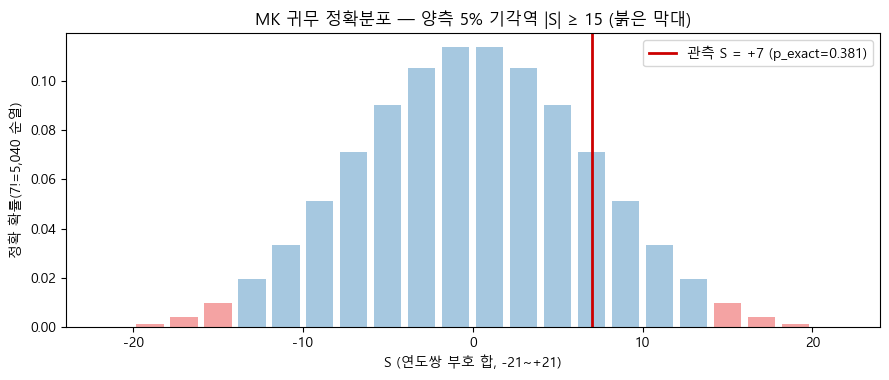

양측 정확 p(|S|>=7): 0.381
기각역 |S| >= 15 → τ >= 0.71 — 21쌍 중 18쌍 이상이 같은 방향이어야 유의


In [2]:
def s_stat(a):
    """MK S 통계량(정의식) — 순열 전수 열거 시각화 전용(판정은 T.mann_kendall 사용)."""
    a = np.asarray(a, float)
    return int(sum(np.sign(a[i + 1:] - a[i]).sum() for i in range(len(a) - 1)))

base = alpha_const.copy()
S_null = np.array([s_stat(perm) for perm in permutations(base)])
vals, counts = np.unique(S_null, return_counts=True)
pmf = counts / counts.sum()

# 양측 5% 임계: P(|S'| >= s) <= 0.05인 최소 s (n=7 무동률에서 S는 홀수만 가능)
tail = {s: float((np.abs(S_null) >= s).mean()) for s in range(1, 22, 2)}
crit = min(s for s, pv in tail.items() if pv <= 0.05)

S_obs = T.mann_kendall(base)["S"]
fig, ax = plt.subplots(figsize=(9, 3.9))
colors = ["#f4a3a3" if abs(v) >= crit else "#a6c8e0" for v in vals]
ax.bar(vals, pmf, width=1.6, color=colors)
ax.axvline(S_obs, color="#c00", lw=2, label=f"관측 S = {S_obs:+d} (p_exact=0.381)")
ax.set_xlabel("S (연도쌍 부호 합, -21~+21)"); ax.set_ylabel("정확 확률(7!=5,040 순열)")
ax.set_title(f"MK 귀무 정확분포 — 양측 5% 기각역 |S| ≥ {crit} (붉은 막대)")
ax.legend()
fig.tight_layout(); plt.show()
print(f"양측 정확 p(|S|>={abs(S_obs)}): {float((np.abs(S_null) >= abs(S_obs)).mean()):.3f}")
print(f"기각역 |S| >= {crit} → τ >= {crit/21:.2f} — 21쌍 중 {int((21+crit)/2)}쌍 이상이 같은 방향이어야 유의")

**관찰**: p<0.05가 되려면 |S|≥15(τ≥0.71), 즉 21쌍 중 18쌍 이상이 같은 방향인 **거의 완전한 단조성**이 필요하다. 우리 궤적은 2021 고점→2024 저점의 실제 굴곡(비단조)을 가지므로 S=+7에 머문다 — 비유의는 "추세 없음"의 증거가 아니라 **비단조 + 저검정력의 산술적 귀결**이다. 이것이 p=0.381을 그대로 보고해도 결론이 흔들리지 않는 이유다.

## **3. [실행] 실데이터 점추정 — MK·Sen**

In [3]:
yrs, alpha_pts = T.latent_trend_points(panel)      # 정렬 점추정 재계산(23·31과 동일 경로)
mk = T.mann_kendall(alpha_pts)
sen = T.sens_slope(alpha_pts)
print(f"정렬 점추정 α̂: {np.round(alpha_pts, 3).tolist()}")
print(f"MK: S={mk['S']:+d} · τ={mk['tau']:+.3f} · 정확 p={mk['p_exact']:.3f}")
print(f"Sen 기울기: {sen:+.4f} SD/년 (21쌍 기울기의 중앙값)")

정렬 점추정 α̂: [0.0, 0.354, 0.474, 0.453, 0.394, 0.298, 0.671]
MK: S=+7 · τ=+0.333 · 정확 p=0.381
Sen 기울기: +0.0595 SD/년 (21쌍 기울기의 중앙값)


## **4. [실행] 부트스트랩 전파 — 추정 불확실성까지 흔들었을 때의 방향**

점추정 MK는 α̂ 7개를 상수처럼 취급한다. 그러나 α̂ 자체가 표본 추정치다 — `mk_with_uncertainty`가 정렬 부트스트랩(B=150)의 α 분포 각각에 MK를 적용해, **추정 불확실성을 통과한 뒤에도** 방향이 유지되는 확률을 계산한다.

**[시각화] 부트스트랩 τ 분포** — 전 부트스트랩 반복에서 τ의 분포와 P(S>0).

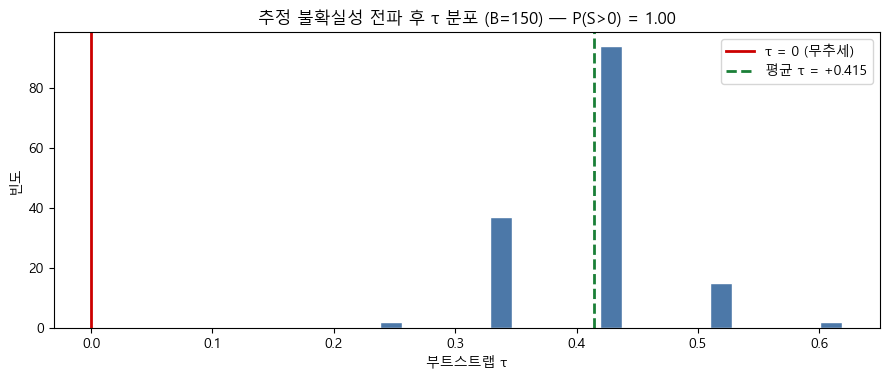

τ 평균 +0.415 · 95% 구간 [+0.333, +0.524] · P(S>0) = 1.00


In [4]:
taus, s_pos, alpha_boot = T.mk_with_uncertainty(panel, B=150)

fig, ax = plt.subplots(figsize=(9, 3.9))
ax.hist(taus, bins=21, color="#4c78a8", edgecolor="white")
ax.axvline(0, color="#c00", lw=2, label="τ = 0 (무추세)")
ax.axvline(np.mean(taus), color="#1a7f37", lw=2, ls="--", label=f"평균 τ = {np.mean(taus):+.3f}")
ax.set_xlabel("부트스트랩 τ"); ax.set_ylabel("빈도")
ax.set_title(f"추정 불확실성 전파 후 τ 분포 (B=150) — P(S>0) = {s_pos:.2f}")
ax.legend()
fig.tight_layout(); plt.show()
print(f"τ 평균 {np.mean(taus):+.3f} · 95% 구간 [{np.quantile(taus, 0.025):+.3f}, {np.quantile(taus, 0.975):+.3f}] · P(S>0) = {s_pos:.2f}")

**관찰**: α̂를 부트스트랩으로 흔든 모든 반복에서 S>0 — **증가 방향이 표집·추정 불확실성에 견고**하다. 점추정 p(크기의 유의성)와 P(S>0)(방향의 견고성)는 서로 다른 질문에 대한 답이므로 모순이 아니다: 전자는 "완전 단조인가", 후자는 "방향이 양인가"를 묻는다.

## **5. [입증] 검증 셀**

In [5]:
# (a) 점추정 — 문서(24 §3): τ=+0.333, p=0.381, Sen=+0.0595
assert mk["S"] == 7 and abs(mk["tau"] - 1/3) < 1e-9
assert abs(mk["p_exact"] - 0.381) <= 0.002, mk["p_exact"]
assert abs(sen - 0.0595) <= 0.001, sen
print(f"(a) 점추정: S=+7 · τ=+0.333 · p=0.381 · Sen=+0.0595 ↔ 문서 일치 PASS")

# (b) 정확분포 — 전수 5,040 · 대칭 · 관측 p 재현
assert len(S_null) == 5040 and abs(float(S_null.mean())) < 1e-9
p_re = float((np.abs(S_null) >= abs(S_obs)).mean())
assert abs(p_re - mk["p_exact"]) <= 1e-9
print(f"(b) 순열 정확분포: 5,040 전수 · 평균 0(대칭) · p 재현 {p_re:.3f} PASS")

# (c) 부트스트랩 — 문서(30 §4): τ 평균 +0.415(95% [+0.333, +0.524]), P(S>0)=1.00
assert s_pos == 1.0, s_pos
assert abs(float(np.mean(taus)) - 0.415) <= 0.05
lo, hi = np.quantile(taus, [0.025, 0.975])
assert abs(lo - 0.333) <= 0.06 and abs(hi - 0.524) <= 0.06, (lo, hi)
print(f"(c) 부트스트랩: P(S>0)={s_pos:.2f} · τ평균 {np.mean(taus):+.3f}(문서 +0.415) · "
      f"95% [{lo:+.3f}, {hi:+.3f}](문서 [+0.333, +0.524]) PASS")

# (d) 검정력 구조 — 기각역 임계 확인(양측 5%에서 |S|>=15, S는 홀수만 가능)
assert crit == 15, crit
print(f"(d) n=7 기각역 |S| >= {crit} — '거의 완전 단조' 요구 구조 확인 PASS")
print("\n검증 (a)~(d) 전부 PASS")

(a) 점추정: S=+7 · τ=+0.333 · p=0.381 · Sen=+0.0595 ↔ 문서 일치 PASS
(b) 순열 정확분포: 5,040 전수 · 평균 0(대칭) · p 재현 0.381 PASS
(c) 부트스트랩: P(S>0)=1.00 · τ평균 +0.415(문서 +0.415) · 95% [+0.333, +0.524](문서 [+0.333, +0.524]) PASS
(d) n=7 기각역 |S| >= 15 — '거의 완전 단조' 요구 구조 확인 PASS

검증 (a)~(d) 전부 PASS


## **6. 종합**

### **연구질문 답**

- **Q1** — 정확분포는 -21~+21의 이산 대칭 분포이고, 양측 5% 기각역은 |S|≥15(τ≥0.71) — 21쌍 중 18쌍 이상의 단조를 요구한다(§2). 실제 궤적의 굴곡(2021 고점·2024 저점)을 감안하면 p<0.05는 애초에 도달하기 어려운 기준이다.
- **Q2** — 점추정 p는 "완전 단조성"의 검정이고 P(S>0)는 "방향의 견고성"이다. 부트스트랩 150회 전부에서 S>0(§4) — 비유의와 방향 견고가 동시에 참이며, 그래서 보고 문장은 "부호 일관 상승 방향(P(S>0)=1.00), 점추정 비유의"가 된다.
- **Q3** — Sen +0.0595/년은 21쌍 기울기의 중앙값일 뿐 구간 추정이 아니다(n=7) — 단독 인용 금지·'참고치만' 등급(`24` DB③)이 이 구조에서 나온다.

### **단계 요약**

| § | 한 일 | 판정 |
|---|------|:---:|
| 2 | 순열 정확분포 5,040 전수 + 기각역 | 구조 확정 |
| 3 | 점추정 MK·Sen 재계산 | 문서 일치 |
| 4 | 부트스트랩 전파 재실행(B=150) | P(S>0)=1.00 |
| 5 | 일괄 assert | **PASS** |

**다음**: `27`(APC 식별 심층) — "그 방향은 누구의 것인가"로.